# Check that changing the length of gates/the drive strength affects cross talk the way we expect 
- doesnt have to be super pretty
- obviously dont use time/freq interms of rabi

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


# Find how params change with scaling rabi freq but keeping it a root X

Fitting parameters for 5.00 MHz: a = 18.47492924076529, b = 0.0002363552181554242
Fitting parameters for 3.83 MHz: a = 10.829663040578263, b = 0.0002364464223297279
Fitting parameters for 2.66 MHz: a = 5.2139353121369565, b = 0.0002368632318652044
Fitting parameters for 1.48 MHz: a = 1.6281711206318685, b = 0.0002374190338734047
Fitting parameters for 0.31 MHz: a = 0.07216756777889664, b = 0.00023633802603877305


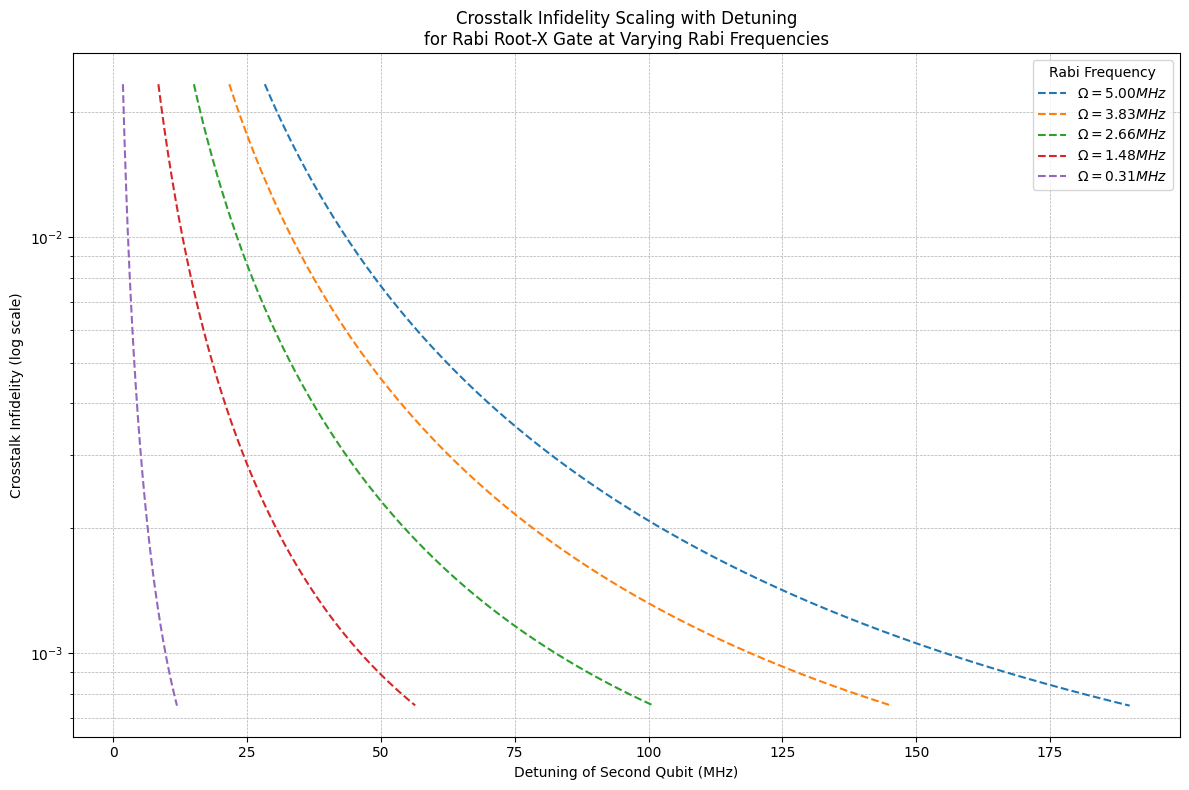

In [23]:
# Define the 1/x function for fitting
def inverse_function(x, a, b):
    return a / x**2 + b

# Function to find peaks, fit 1/x curve, and plot
def fit_and_plot(detunings, infidelities, label, color):
    # Find the peaks in the infidelity data
    peaks, _ = find_peaks(infidelities)

    # Extract the x (detunings) and y (infidelities) values at the peaks
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]

    # Fit the 1/x curve to the peaks
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)

    # Generate the fitted curve
    x_fit = np.linspace(min(x_peaks), max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    a, b = params
    print(f"Fitting parameters for {label}: a = {a}, b = {b}")
    # Plot the results
    # plt.semilogy(detunings, infidelities, label=f"{label} Infidelity", color=color)
    # plt.scatter(x_peaks, y_peaks, color=color, marker='o', label=f"{label} Peaks")
    plt.semilogy(x_fit, y_fit, '--', label=f"$\\Omega= {label}$")







plt.figure(figsize=(12, 8))




for rabi_freq in np.linspace(0.005, 0.005/16, 5):
    evaluation_time = 1 / (4 * rabi_freq)
    detunings = np.linspace(0, 40 * rabi_freq, 100)

    fids_1 = []
    fids_2 = []
    fids_combined = []

    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
        natural_freq=natural_freq + 0, driving_freq=driving_freq,
        rabi_freq=rabi_freq, atol=tol, rtol=tol
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    for detuning in detunings:
        times, Us_driving_frame = qt.calculate_unitaries(
            1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
            natural_freq=natural_freq + detuning, driving_freq=driving_freq,
            rabi_freq=rabi_freq, atol=tol, rtol=tol
        )

        fids_1.append(fid_1)

        effective_rabi_freq = np.sign(detuning) * np.sqrt(rabi_freq**2 + detuning**2)
        Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
        fids_2.append(fid_2)

        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

    # Convert rabi freq to MHz for the legend
    label_str = f"{rabi_freq * 1e3:.2f} MHz"
    fit_and_plot(detunings * 1e3, 1 - np.array(final_fids_combined_rabi), label_str, steel_blue)

# Plot formatting
plt.xlabel("Detuning of Second Qubit (MHz)")
plt.ylabel("Crosstalk Infidelity (log scale)")
plt.title("Crosstalk Infidelity Scaling with Detuning\nfor Rabi Root-X Gate at Varying Rabi Frequencies")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Rabi Frequency")
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/fourier_scaling_unnormalised_rabi.png', dpi=600)
plt.show()

# Now show that if you normalise the detuning its all the same

Fitting parameters for 5.00 MHz: a = 738997.1696320333, b = 0.00023635521819680489
Fitting parameters for 3.83 MHz: a = 738997.0813147378, b = 0.0002364464251187671
Fitting parameters for 2.66 MHz: a = 738971.5928614803, b = 0.00023686323532072054
Fitting parameters for 1.48 MHz: a = 738946.1394900284, b = 0.0002374190365516786
Fitting parameters for 0.31 MHz: a = 738995.8940594143, b = 0.00023633802591452413


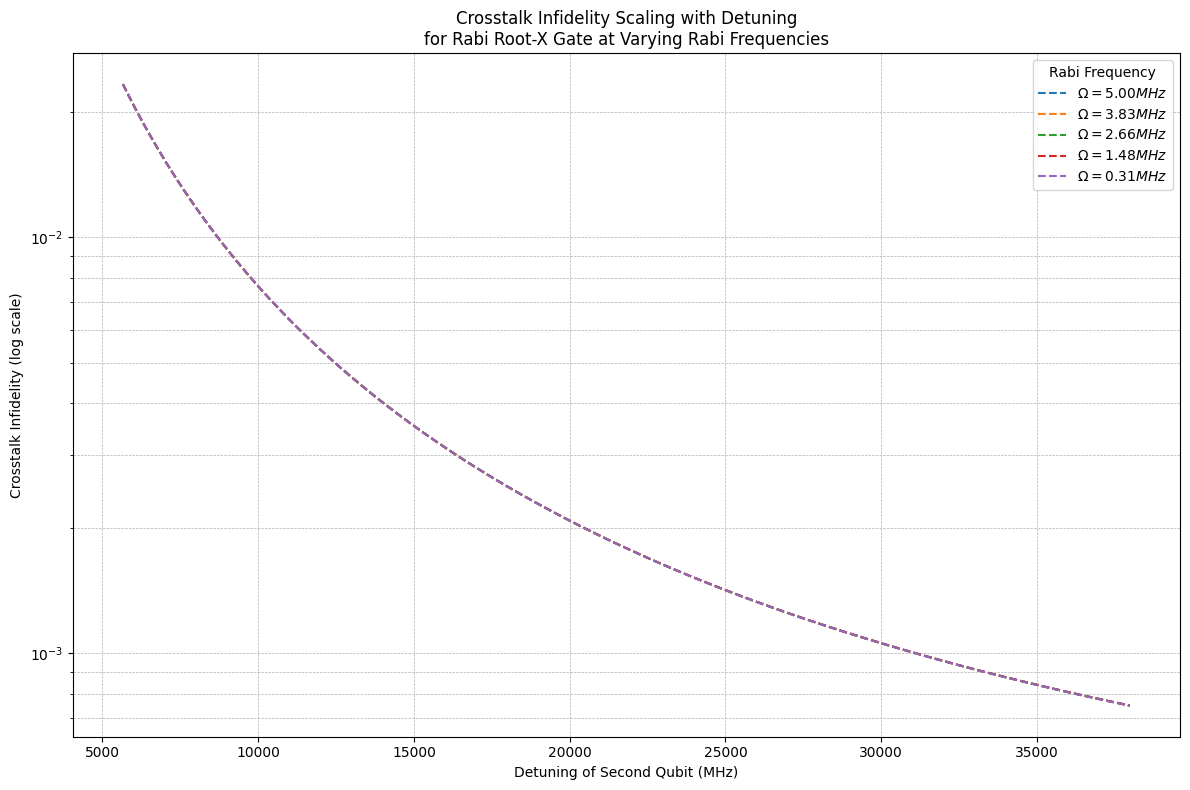

In [22]:
# Define the 1/x function for fitting
def inverse_function(x, a, b):
    return a / x**2 + b

# Function to find peaks, fit 1/x curve, and plot
def fit_and_plot(detunings, infidelities, label, color):
    # Find the peaks in the infidelity data
    peaks, _ = find_peaks(infidelities)


    # Extract the x (detunings) and y (infidelities) values at the peaks
    x_peaks = detunings[peaks][1:]
    y_peaks = infidelities[peaks][1:]

    # Fit the 1/x curve to the peaks
    params, _ = curve_fit(inverse_function, x_peaks, y_peaks)

    # Generate the fitted curve
    x_fit = np.linspace(min(x_peaks), max(x_peaks), 500)
    y_fit = inverse_function(x_fit, *params)
    a, b = params
    print(f"Fitting parameters for {label}: a = {a}, b = {b}")
    # Plot the results
    # plt.semilogy(detunings, infidelities, label=f"{label} Infidelity", color=color)
    # plt.scatter(x_peaks, y_peaks, color=color, marker='o', label=f"{label} Peaks")
    plt.semilogy(x_fit, y_fit, '--', label=f"$\\Omega= {label}$")






plt.figure(figsize=(12, 8))




for rabi_freq in np.linspace(0.005, 0.005/16, 5):
    evaluation_time = 1 / (4 * rabi_freq)
    detunings = np.linspace(0, 40 * rabi_freq, 100)

    fids_1 = []
    fids_2 = []
    fids_combined = []

    times, Us_driving_frame = qt.calculate_unitaries(
        1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
        natural_freq=natural_freq + 0, driving_freq=driving_freq,
        rabi_freq=rabi_freq, atol=tol, rtol=tol
    )
    fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

    for detuning in detunings:
        times, Us_driving_frame = qt.calculate_unitaries(
            1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa,
            natural_freq=natural_freq + detuning, driving_freq=driving_freq,
            rabi_freq=rabi_freq, atol=tol, rtol=tol
        )

        fids_1.append(fid_1)

        effective_rabi_freq = np.sign(detuning) * np.sqrt(rabi_freq**2 + detuning**2)
        Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
        fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
        fids_2.append(fid_2)

        fid_combined = (np.abs((6 * fid_1 - 2) * (6 * fid_2 - 2)) + 4) / 20
        fids_combined.append(fid_combined)

    final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

    # Convert rabi freq to MHz for the legend
    label_str = f"{rabi_freq * 1e3:.2f} MHz"

    detunings_normalised = detunings / rabi_freq
    fit_and_plot(detunings_normalised * 1e3, 1 - np.array(final_fids_combined_rabi), label_str, steel_blue)

# Plot formatting
plt.xlabel("Detuning of Second Qubit (MHz)")
plt.ylabel("Crosstalk Infidelity (log scale)")
plt.title("Crosstalk Infidelity Scaling with Detuning\nfor Rabi Root-X Gate at Varying Rabi Frequencies")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Rabi Frequency")
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/fourier_scaling_unnormalised_rabi.png', dpi=600)
plt.show()

## To note here
- it is actually 1/x^2 scaling - I suppose this was known/expected from th powerspectrum of a top hat
- we see cross talk is larger at larger detunings for larger rabi frequency
- that is to say we can compress the above plots to look the same (within error) by plotting them with their normalised detuning (ie interms of their rabi freq)
- yeah so if you are 40*rabi freq away from any of these you will get the same crosstalk

# Repeat for CCD - out of interest mainly

Fitting parameters for 0.005: a = 9.93630315749037e-06, b = 0.005407163046518241
Fitting parameters for 0.003828125: a = 5.824470612958083e-06, b = 0.005407576599929108
Fitting parameters for 0.00265625: a = 2.804281296967598e-06, b = 0.005408317603282285
Fitting parameters for 0.0014843750000000005: a = 8.757311908621571e-07, b = 0.005409467477165847
Fitting parameters for 0.0003125: a = 3.881370976069733e-08, b = 0.0054070320145932615


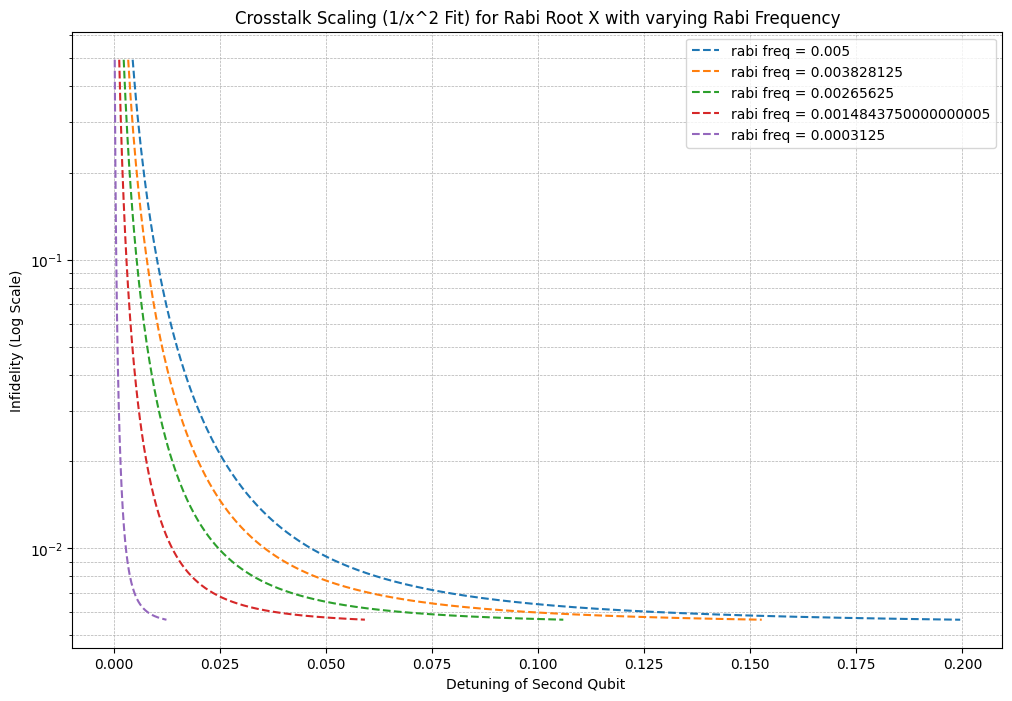

In [ ]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10



# CCD parameters


# Integration parameters
tol = 10**-5
evaluation_points = 400
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 0.2, 400)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians._rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m, 
                            atol=tol, rtol=tol)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol, rtol=tol)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_ccd = [fid[-1] for fid in fids_combined]

# Is detuning the same as time??
- for the same detuning - vary time
- for same time vary detuning

- this is only for the second qubit - ie not combined fidelity

## Detunings

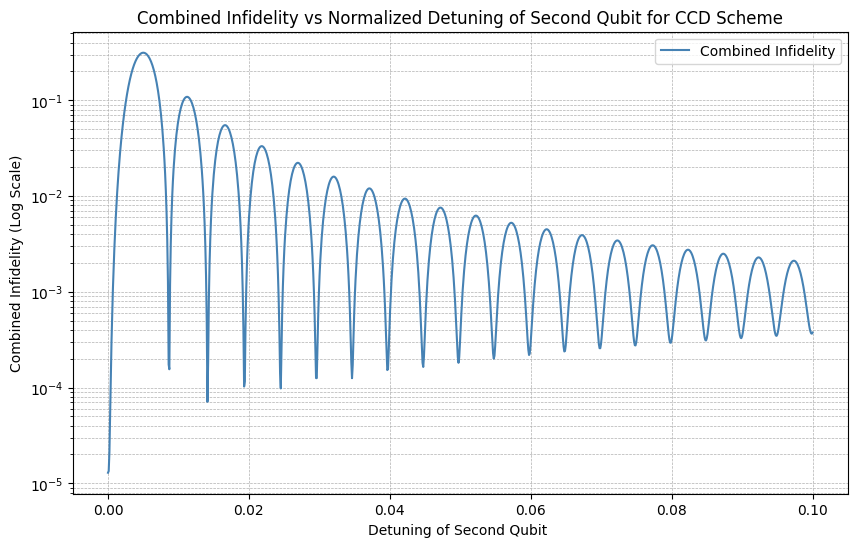

In [76]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-5
evaluation_points = 200


evaluation_time = 1/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 0.1, 1000)



fids_1 = []
fids_2 = []
fids_combined = []



for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq, atol=tol, rtol=tol)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)



# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


# Plot the results
# find combdined infidelity
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit ")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


## Time

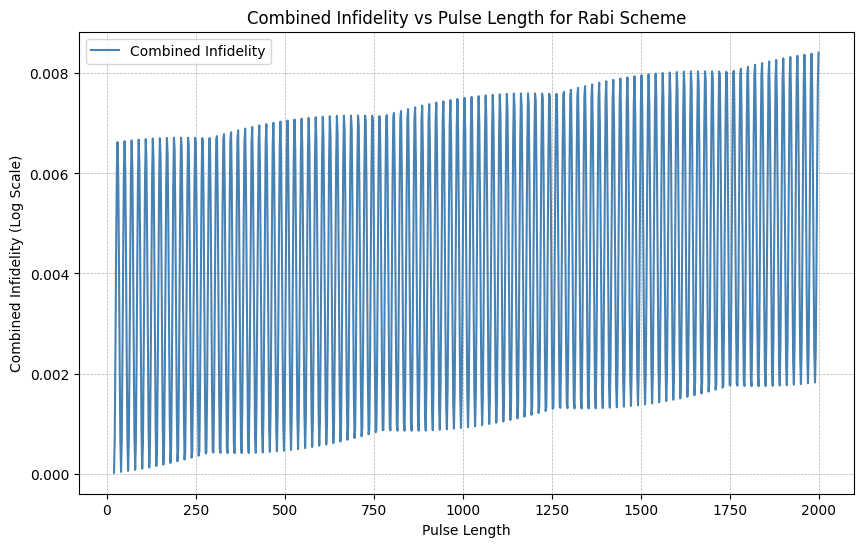

In [77]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-5
evaluation_points = 200


evaluation_times = np.linspace(0.1, 10, 1000)/rabi_freq


# iteration parameters
detuning  = 0.05



fids_1 = []
fids_2 = []
fids_combined = []



for evaluation_time in evaluation_times:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq, atol=tol, rtol=tol)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)



# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


# Plot the results
# find combdined infidelity
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs evaluation time on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.plot(evaluation_times, infidelities_2_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Pulse Length")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Pulse Length for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


Ah yes - the fidelity is only realy relevant at the points we do the gat we are testing for

$\left(\frac{2Ax\sin\left(x\cdot0.3\right)}{\left(x\cdot0.3\right)}\right)^{2}$ - if you plot this you see that it is just sin - and that is the power spectrum at a specific detuning with varying pulse length

# So I think Ignore the first qubit ad just plot this stuff vs rabi with exactly the same values

In [81]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_ccd = [fid[-1] for fid in fids_2]

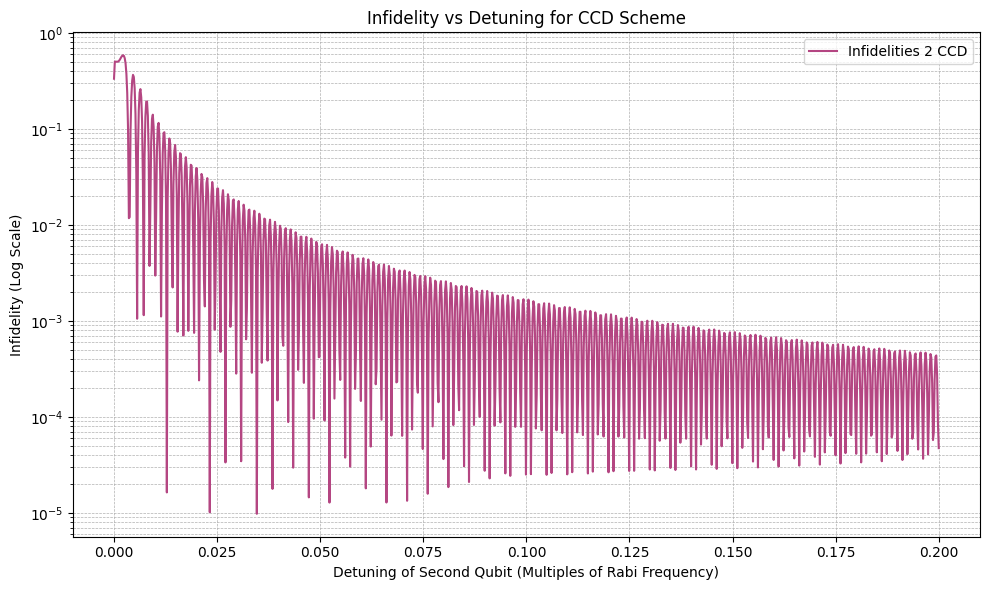

In [ ]:
# Plot the results
infidelities_2_ccd = 1 - np.array(final_fids_2_ccd)  # Calculate infidelities
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_ccd, label="Infidelities 2 CCD", color=plum)
plt.xlabel("Detuning of Second Qubit")
plt.ylabel("Infidelity (Log Scale)")
plt.title("Infidelity vs Detuning for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)



fids_1 = []
fids_2 = []
fids_combined = []



for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)


    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


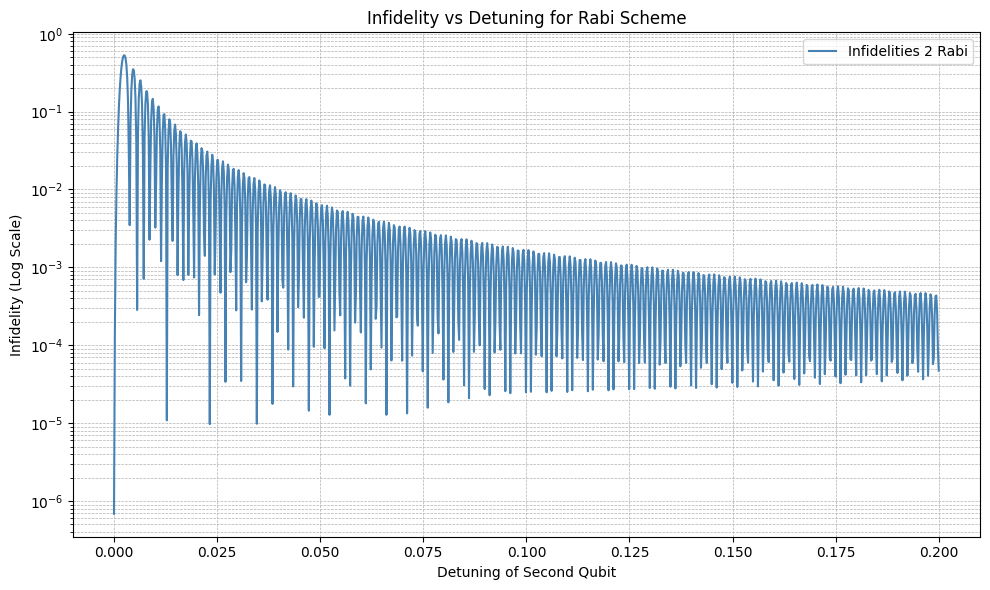

In [89]:
# Plot the results
infidelities_2_rabi = 1 - np.array(final_fids_2_rabi)  # Calculate infidelities
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Infidelities 2 Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit")
plt.ylabel("Infidelity (Log Scale)")
plt.title("Infidelity vs Detuning for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

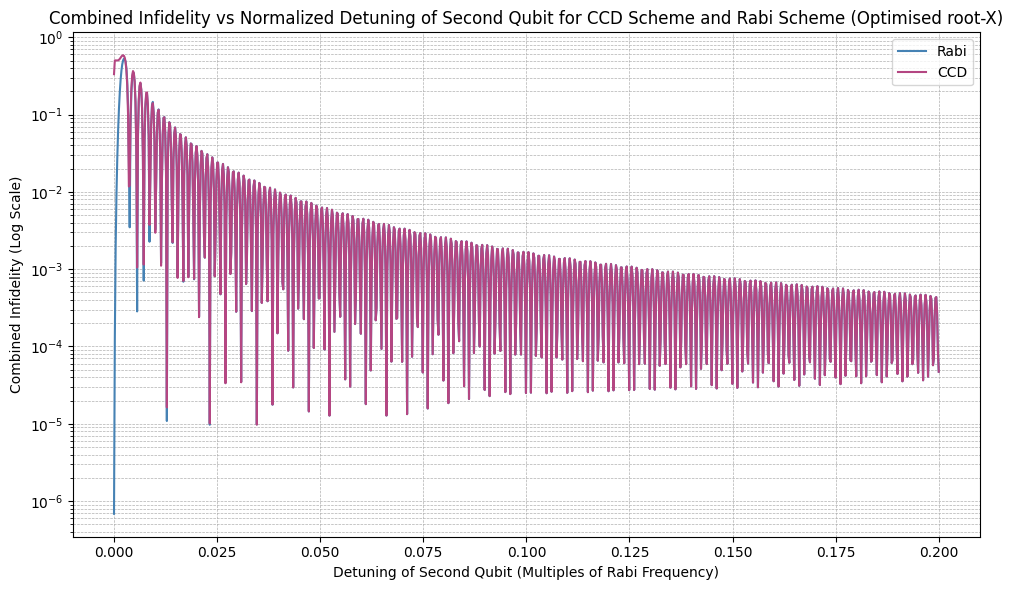

In [91]:
# find combdined infidelity
infidelities_2_ccd = 1-np.array(final_fids_2_ccd)
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Rabi", color=steel_blue)
plt.semilogy(detunings, infidelities_2_ccd, label="CCD", color=plum)

plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("dirty_root_x_scaling.png", dpi=300)
plt.show()

